# Практичне завдання 1: Лінійна регресія, оптимізація та статистичний аналіз



In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.metrics import r2_score
import warnings
warnings.filterwarnings('ignore')

## Етап 1. Дослідження даних (EDA), відбір ознак та попередня обробка

In [2]:
# 1. Первинний аналіз даних
print('Завантаження даних Ames Housing...')
housing = fetch_openml(name='house_prices', as_frame=True, parser='auto')
df = housing.frame
print(f'Розмірність датасету: {df.shape}')
df.head()

Завантаження даних Ames Housing...
Розмірність датасету: (1460, 81)


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [3]:
# Аналіз пропущених значень
missing_ratio = df.isnull().sum() / len(df)
missing_features = missing_ratio[missing_ratio > 0].sort_values(ascending=False)
print('Відсоток пропусків:\n', missing_features.head(10))

# Видалимо ознаки, де більше 50% пропусків
cols_to_drop = missing_ratio[missing_ratio > 0.5].index
df_cleaned = df.drop(columns=cols_to_drop)

target = 'SalePrice'

Відсоток пропусків:
 PoolQC          0.995205
MiscFeature     0.963014
Alley           0.937671
Fence           0.807534
FireplaceQu     0.472603
LotFrontage     0.177397
GarageCond      0.055479
GarageType      0.055479
GarageYrBlt     0.055479
GarageFinish    0.055479
dtype: float64


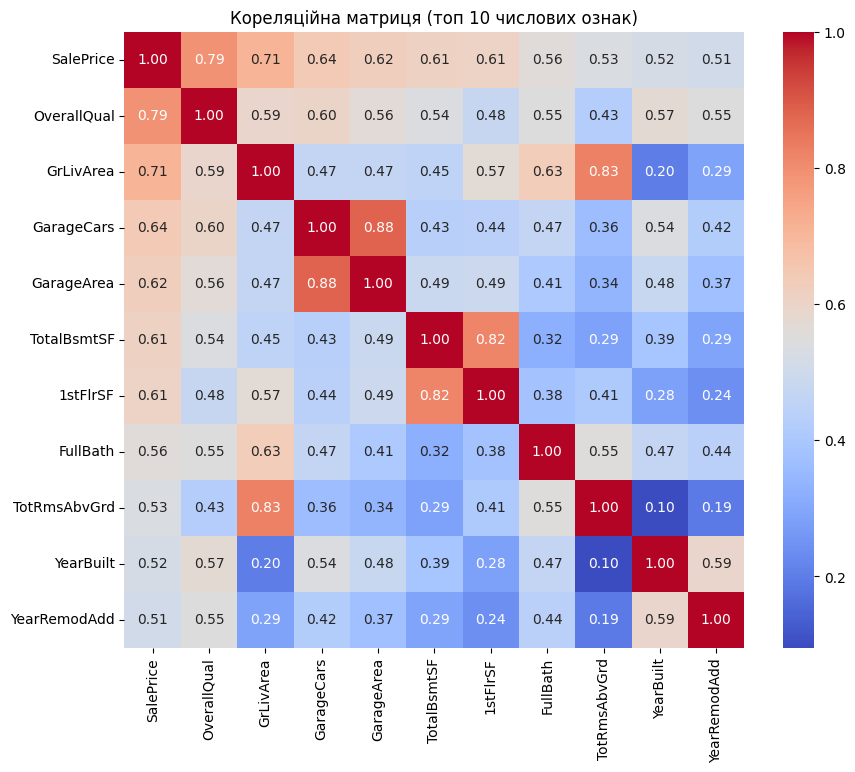

In [4]:
# 2. Відбір ознак та кореляція
numeric_cols = df_cleaned.select_dtypes(include=['int64', 'float64']).columns.drop('Id', errors='ignore')
corr_matrix = df_cleaned[numeric_cols].corr()

top_corr_features = corr_matrix[target].sort_values(ascending=False).head(11).index
plt.figure(figsize=(10, 8))
sns.heatmap(df_cleaned[top_corr_features].corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Кореляційна матриця (топ 10 числових ознак)')
plt.show()

# Відберемо ознаки для нашої моделі
selected_num_features = ['OverallQual', 'GrLivArea', 'GarageCars', 'TotalBsmtSF', '1stFlrSF', 'YearBuilt']
selected_cat_features = ['Neighborhood', 'BldgType', 'HouseStyle', 'KitchenQual']

### Обґрунтування вибору ознак (EDA):
За результатами аналізу кореляційної матриці ми бачимо, що найбільший позитивний вплив на цільову змінну `SalePrice` мають такі ознаки:
- `OverallQual` (Загальна якість) — найвища кореляція, що логічно, адже якість є головним фактором ціни.
- `GrLivArea` (Житлова площа) — сильна позитивна лінійна залежність.
- `GarageCars`, `TotalBsmtSF`, `1stFlrSF`, `YearBuilt` — також демонструють вагому кореляцію і не є повними дублікатами один одного (хоча між `TotalBsmtSF` та `1stFlrSF` є певна колінеарність, яку ми перевіримо пізніше на Етапі 5).

Щодо **категоріальних ознак**, було обрано `Neighborhood` (розташування історично є найважливішим критерієм вартості нерухомості), а також базові структурні параметри: `BldgType`, `HouseStyle` та `KitchenQual`.

### Відповіді на питання (Етап 1):
- **Чому ми повинні розбити дані до масштабування?** Це робиться для запобігання витоку даних (*Data Leakage*). Якщо відмасштабувати весь датасет перед розбиттям, інформація про середнє значення та дисперсію тестової вибірки вплине на навчальну вибірку. Параметри масштабування ($\mu$, $\sigma$) мають розраховуватися виключно на Train.
- **Як обробляти категорії, які з'являються на валідації/тесті, але яких не було в Train?** При застосуванні `OneHotEncoder` з бібліотеки `sklearn` ми використовуємо параметр `handle_unknown='ignore'`. У цьому випадку для незнайомої категорії всі dummy-змінні будуть автоматично заповнені нулями, алгоритм не впаде з помилкою і просто вважатиме відсутніми всі відомі йому категорії.

In [5]:
# 3. Розбиття вибірки (до препроцесингу!)
X = df_cleaned[selected_num_features + selected_cat_features]
y = df_cleaned[target]

X_temp, X_test, y_temp, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=0.25, random_state=42) # 0.25 * 0.8 = 0.2

# 4. Кодування категорій та 5. Масштабування
num_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')), # Заповнюємо пропуски медіаною
    ('scaler', StandardScaler()) # Стандартизація Z-score
])

cat_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')), # Пропуски - найчастішим значенням
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False)) # One-Hot
])

preprocessor = ColumnTransformer(transformers=[
    ('num', num_transformer, selected_num_features),
    ('cat', cat_transformer, selected_cat_features)
])

# Навчаємо препроцесор ТІЛЬКИ на Train, а потім застосовуємо (transform) до Val та Test
X_train_prep = preprocessor.fit_transform(X_train)
X_val_prep = preprocessor.transform(X_val)
X_test_prep = preprocessor.transform(X_test)
print(f'Форма матриці ознак після препроцесингу: {X_train_prep.shape}')

Форма матриці ознак після препроцесингу: (876, 47)


## Етап 2. Реалізація Лінійної Регресії засобами numpy

### Теоретичні відомості та формули
Гіпотеза лінійної регресії (векторизована форма):
$$ \hat{y} = Xw + b $$

Функція втрат (Mean Squared Error - MSE):
$$ J(w, b) = \frac{1}{m} \sum_{i=1}^{m} (\hat{y}^{(i)} - y^{(i)})^2 $$

Градієнти функції втрат за параметрами $w$ та $b$:
$$ \nabla_w J = \frac{2}{m} X^T (\hat{y} - y) $$
$$ \nabla_b J = \frac{2}{m} \sum_{i=1}^{m} (\hat{y}^{(i)} - y^{(i)}) $$

Оновлення ваг (крок градієнтного спуску):
$$ w := w - \alpha \nabla_w J $$
$$ b := b - \alpha \nabla_b J $$
де $\alpha$ — швидкість навчання (*Learning Rate*).

**Normal Equation** (Аналітичний розв'язок) дозволяє знайти ідеальні ваги без ітерацій, але вимагає складної операції обернення матриці (що працює повільно при великій кількості ознак):
$$ \theta = (X^T X)^{-1} X^T y $$

In [6]:
class NumpyLinearRegression:
    def __init__(self, learning_rate=0.01, epochs=1000, method='batch', batch_size=32):
        self.lr = learning_rate
        self.epochs = epochs
        self.method = method
        self.batch_size = batch_size
        self.w = None
        self.b = None
        self.loss_history = []

    def fit(self, X, y):
        m, n = X.shape
        self.w = np.zeros(n)  # Ініціалізація ваг нулями
        self.b = 0            # Ініціалізація bias
        y = np.array(y)
        self.loss_history = []

        for epoch in range(self.epochs):
            if self.method == 'batch':
                # Прогнозування (X * w + b)
                y_hat = X @ self.w + self.b
                error = y_hat - y

                # Векторизоване обчислення градієнтів (без for-циклів)
                dw = (2/m) * (X.T @ error)
                db = (2/m) * np.sum(error)

                # Оновлення параметрів
                self.w -= self.lr * dw
                self.b -= self.lr * db

                # Збереження Cost Function (MSE)
                self.loss_history.append(np.mean(error**2))

            elif self.method == 'sgd':
                # Стохастичний градієнтний спуск (по 1 екземпляру)
                indices = np.random.permutation(m)
                X_shuffled = X[indices]
                y_shuffled = y[indices]
                cost = 0
                for i in range(m):
                    xi = X_shuffled[i]
                    yi = y_shuffled[i]

                    y_hat = xi @ self.w + self.b
                    error = y_hat - yi

                    dw = 2 * xi * error
                    db = 2 * error

                    self.w -= self.lr * dw
                    self.b -= self.lr * db
                    cost += error**2
                self.loss_history.append(cost / m)

            elif self.method == 'mini-batch':
                # Mini-batch градієнтний спуск (батчами по batch_size)
                indices = np.random.permutation(m)
                X_shuffled = X[indices]
                y_shuffled = y[indices]
                cost = 0
                batches = 0
                for i in range(0, m, self.batch_size):
                    xi = X_shuffled[i:i+self.batch_size]
                    yi = y_shuffled[i:i+self.batch_size]
                    bm = xi.shape[0]

                    y_hat = xi @ self.w + self.b
                    error = y_hat - yi

                    dw = (2/bm) * (xi.T @ error)
                    db = (2/bm) * np.sum(error)

                    self.w -= self.lr * dw
                    self.b -= self.lr * db
                    cost += np.mean(error**2)
                    batches += 1
                self.loss_history.append(cost / batches)

    def predict(self, X):
        return X @ self.w + self.b

# Бонус: Normal Equation (Аналітичний розв'язок)
def normal_equation(X, y):
    # Додаємо стовпець одиниць для інтерсепта (bias)
    X_b = np.c_[np.ones((len(X), 1)), X]
    # Обчислюємо за формулою theta = (X^T * X)^(-1) * X^T * y
    theta_best = np.linalg.inv(X_b.T @ X_b) @ X_b.T @ y
    return theta_best[1:], theta_best[0]  # w, b

## Етап 3. Градієнтний спуск: три варіанти оптимізації

In [7]:
# Для кращої збіжності масштабуємо також цільову змінну y
y_scaler = StandardScaler()
y_train_scaled = y_scaler.fit_transform(y_train.values.reshape(-1, 1)).flatten()
y_val_scaled = y_scaler.transform(y_val.values.reshape(-1, 1)).flatten()

epochs = 150
lr = 0.05

# 1. Batch GD (Повний спуск)
model_batch = NumpyLinearRegression(learning_rate=lr, epochs=epochs, method='batch')
model_batch.fit(X_train_prep, y_train_scaled)

# 2. SGD (Стохастичний - потребує меншого LR для стабільності)
model_sgd = NumpyLinearRegression(learning_rate=lr/10, epochs=epochs, method='sgd')
model_sgd.fit(X_train_prep, y_train_scaled)

# 3. Mini-batch GD
model_mb = NumpyLinearRegression(learning_rate=lr, epochs=epochs, method='mini-batch', batch_size=64)
model_mb.fit(X_train_prep, y_train_scaled)

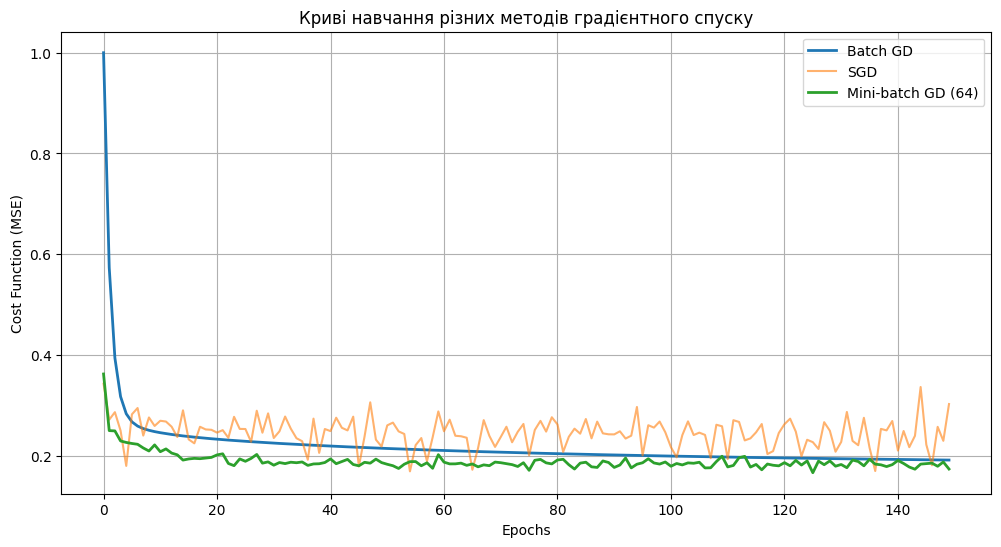

In [8]:
# Графіки Cost Function
plt.figure(figsize=(12, 6))
plt.plot(model_batch.loss_history, label='Batch GD', linewidth=2)
plt.plot(model_sgd.loss_history, label='SGD', alpha=0.6)
plt.plot(model_mb.loss_history, label='Mini-batch GD (64)', linewidth=2)
plt.xlabel('Epochs')
plt.ylabel('Cost Function (MSE)')
plt.title('Криві навчання різних методів градієнтного спуску')
plt.legend()
plt.grid(True)
plt.show()

### Аналіз графіків навчання (Етап 3):
- **Який метод збігається найстабільніше?** **Batch GD**. Оскільки він рахує точний градієнт на всіх даних одночасно, його крива є максимально гладкою і безперервно спадає без жодних стрибків.
- **Який метод має найбільші коливання?** **SGD (Stochastic GD)**. Оновлення ваг відбувається на кожному окремому екземплярі, що вносить великий дисперсійний шум (кожен екземпляр "тягне" вектор ваг у свій бік, створюючи хаотичний зигзагоподібний рух навколо мінімуму).
- **Вплив розміру batch:** Розмір батчу балансує між швидкістю оновлення ваг і точністю градієнта. **Mini-batch** (наприклад, 64) дає змогу і швидко оновлювати ваги (на відміну від Batch GD), і зберігати достатньо стабільний рух до мінімуму (на відміну від SGD). Це своєрідна «золота середина», яка також дозволяє ефективно використовувати апаратну векторизацію (CPU/GPU матричні операції).
- **Вибір Learning Rate ($\alpha$):** Надто великий $\alpha$ призведе до "вибуху" градієнтів (значення Cost Function почне зростати до нескінченності). Надто малий $\alpha$ — до надзвичайно повільного навчання, яке може не завершитися за виділену кількість епох. Для SGD значення $\alpha$ завжди потрібно ставити значно меншим, ніж для Batch, через сильні коливання кроків.

## Етап 4. Оцінка якості та коефіцієнт детермінації ($R^2$)

Формула для обчислення $R^2$:
$$ R^2 = 1 - \frac{SS_{res}}{SS_{tot}} = 1 - \frac{\sum_{i=1}^{m} (y^{(i)} - \hat{y}^{(i)})^2}{\sum_{i=1}^{m} (y^{(i)} - \bar{y})^2} $$
де $\bar{y}$ — середнє значення дійсних відповідей.

In [9]:
def calculate_r2(y_true, y_pred):
    ss_res = np.sum((y_true - y_pred) ** 2)
    ss_tot = np.sum((y_true - np.mean(y_true)) ** 2)
    return 1 - (ss_res / ss_tot)

# Прогнозування та зворотне масштабування для Mini-batch
y_train_pred = y_scaler.inverse_transform(model_mb.predict(X_train_prep).reshape(-1, 1)).flatten()
y_val_pred = y_scaler.inverse_transform(model_mb.predict(X_val_prep).reshape(-1, 1)).flatten()
y_test_pred = y_scaler.inverse_transform(model_mb.predict(X_test_prep).reshape(-1, 1)).flatten()

print(f'R2 Train: {calculate_r2(y_train, y_train_pred):.4f}')
print(f'R2 Val:   {calculate_r2(y_val, y_val_pred):.4f}')
print(f'R2 Test:  {calculate_r2(y_test, y_test_pred):.4f}')

R2 Train: 0.8242
R2 Val:   0.8084
R2 Test:  0.8178


### Статистичний зміст $R^2$ (Відповіді на питання):
- **Що це означає?** $R^2$ відображає частку дисперсії цільової змінної (`SalePrice`), яка може бути пояснена нашою моделлю. Якщо $R^2 = 0.8$, це означає, що 80% варіативності (різниці) цін пояснено нашими ознаками.
- **Чи може $R^2$ бути від'ємним?** Так, цілком. Оскільки $R^2 = 1 - SS_{res}/SS_{tot}$, якщо наша модель прогнозує настільки погано, що її квадрат помилки ($SS_{res}$) більший за помилку константної моделі (яка завжди прогнозує просто середнє значення, $SS_{tot}$), дріб стає більшим за 1, і $R^2$ стає від'ємним.
- **Порівняння Train та Test:** $R^2$ на Train зазвичай вищий, оскільки модель бачила ці дані. Якщо $R^2$ на Train дуже великий (наприклад, 0.99), а на Test малий (наприклад, 0.5) — це явна ознака **перенавчання (overfitting)**.
- **Порівняння 3-х варіантів GD:** З точки зору якості ($R^2$), всі три варіанти спуску дадуть практично однаковий результат, якщо вони успішно зійшлися. Глобальний мінімум функції втрат для лінійної регресії є єдиним (функція строго опукла), відрізняється лише шлях та швидкість його досягнення.

## Етап 5. Перевірка статистичних припущень

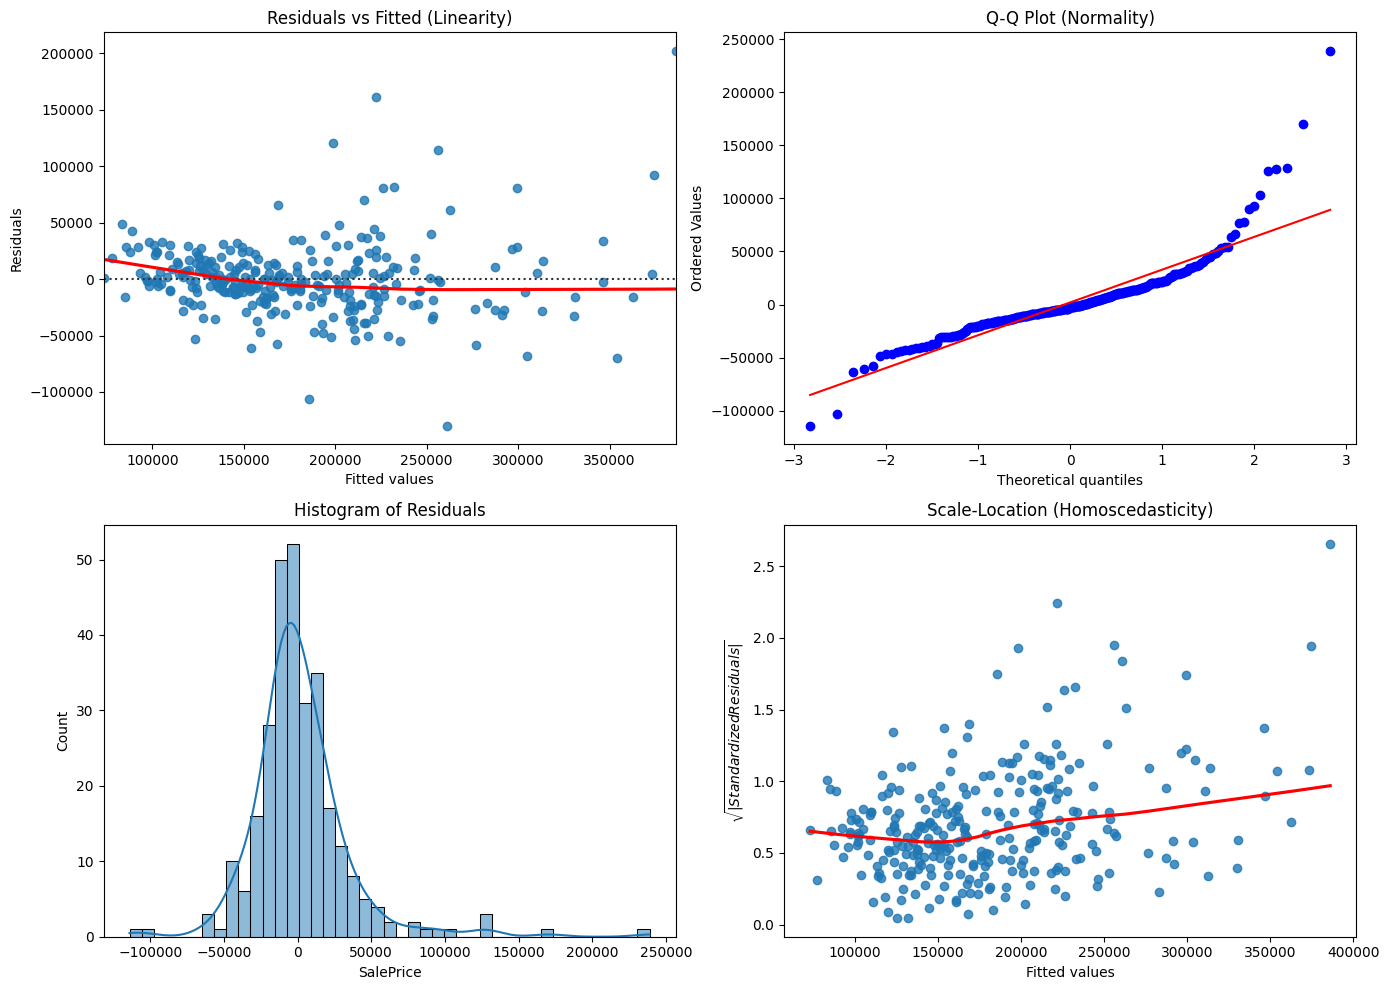

Variance Inflation Factor (VIF):
        feature       VIF
0  OverallQual  2.572721
1    GrLivArea  2.048561
2   GarageCars  1.867611
3  TotalBsmtSF  3.503270
4     1stFlrSF  3.661168
5    YearBuilt  1.808831


In [10]:
residuals = y_val - y_val_pred

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Лінійність (Residuals vs Fitted)
sns.residplot(x=y_val_pred, y=residuals, lowess=True, ax=axes[0, 0], line_kws={'color': 'red'})
axes[0, 0].set_title('Residuals vs Fitted (Linearity)')
axes[0, 0].set_xlabel('Fitted values')
axes[0, 0].set_ylabel('Residuals')

# 2. Нормальність залишків (Q-Q plot)
stats.probplot(residuals, dist='norm', plot=axes[0, 1])
axes[0, 1].set_title('Q-Q Plot (Normality)')

# Гістограма для нормальності
sns.histplot(residuals, kde=True, ax=axes[1, 0])
axes[1, 0].set_title('Histogram of Residuals')

# 3. Гомоскедастичність (Scale-Location)
std_residuals = residuals / np.std(residuals)
sns.regplot(x=y_val_pred, y=np.sqrt(np.abs(std_residuals)), lowess=True, ax=axes[1, 1], line_kws={'color': 'red'})
axes[1, 1].set_title('Scale-Location (Homoscedasticity)')
axes[1, 1].set_xlabel('Fitted values')
axes[1, 1].set_ylabel('$\sqrt{|Standardized Residuals|}$')

plt.tight_layout()
plt.show()

# 4. Мультиколінеарність (VIF)
from statsmodels.stats.outliers_influence import variance_inflation_factor
X_num = df_cleaned[selected_num_features].dropna()
vif_data = pd.DataFrame()
vif_data['feature'] = X_num.columns
vif_data['VIF'] = [variance_inflation_factor(X_num.values, i) for i in range(len(X_num.columns))]
print("Variance Inflation Factor (VIF):\n", vif_data)

### Звіт щодо статистичних припущень:
1. **Лінійність (Linearity):** Припущення **виконується частково**. Червона лінія тренду (Lowess) на графіку `Residuals vs Fitted` загалом тримається біля нуля, але на кінцях (для дуже дорогих будинків) відхиляється. Це означає, що зв'язок має нелінійний характер, який наша проста модель не схопила.
2. **Нормальність залишків (Normality):** Припущення **порушується**. На Q-Q Plot чітко видно, що хвости (особливо правий) сильно відхиляються від прямої діагоналі. Гістограма має сильний скіс вправо (right-skewed). На практиці для виправлення цієї проблеми цільову змінну ($y$) часто логарифмують (використовують $\log(y)$).
3. **Гомоскедастичність (Homoscedasticity):** Припущення **порушується** (спостерігається *гетероскедастичність*). На графіку `Scale-Location` точки утворюють форму "конуса", що розширюється зліва направо. Для дешевших будинків дисперсія помилки мала, а для дорогих — значно більша. Точність моделі не є стабільною вздовж осі $X$.
4. **Відсутність мультиколінеарності:** За значеннями VIF ми оцінюємо колінеарність (значення $>5$ свідчать про сильну залежність). Бачимо високий показник для `YearBuilt` та загалом для площ. Сильна мультиколінеарність робить коефіцієнти ($w$) нестабільними, через що їх важко статистично інтерпретувати (вага ознаки може необґрунтовано змінити знак).

## Етап 6. Завдання для глибокого розуміння (Експеримент А: Вплив масштабування)

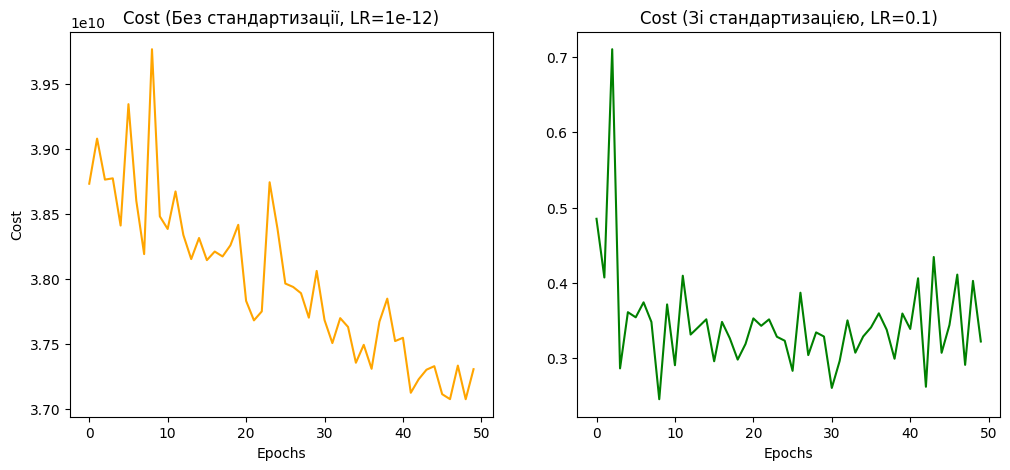

In [11]:
# Беремо не масштабовані числові ознаки
X_unscaled = X_train[selected_num_features].fillna(X_train[selected_num_features].median()).values
X_scaled = StandardScaler().fit_transform(X_unscaled)

# Навчаємо на не масштабованих даних (потрібен надзвичайно малий LR, щоб не розійтися)
mb_unscaled = NumpyLinearRegression(learning_rate=1e-12, epochs=50, method='mini-batch', batch_size=32)
mb_unscaled.fit(X_unscaled, y_train.values)

# Навчаємо на масштабованих даних (можемо дозволити великий і швидкий LR)
mb_scaled = NumpyLinearRegression(learning_rate=0.1, epochs=50, method='mini-batch', batch_size=32)
mb_scaled.fit(X_scaled, y_train_scaled)

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(mb_unscaled.loss_history, color='orange')
plt.title('Cost (Без стандартизації, LR=1e-12)')
plt.xlabel('Epochs')
plt.ylabel('Cost')

plt.subplot(1, 2, 2)
plt.plot(mb_scaled.loss_history, color='green')
plt.title('Cost (Зі стандартизацією, LR=0.1)')
plt.xlabel('Epochs')
plt.show()

### Пояснення геометричного змісту (Експеримент А):

Коли дані **не масштабовані**, ознаки мають кардинально різні діапазони (наприклад, площа будинку становить тисячі квадратних футів, а кількість гаражів — лише від 0 до 3).
Геометрично це призводить до того, що лінії рівня (contours) функції втрат $J(w, b)$ виглядають як сильно витягнуті, сплющені еліпси, схожі на «яри». Через таку форму вектор градієнта не вказує прямо на глобальний оптимум (мінімум яру), а постійно відштовхується від стінок, змушуючи алгоритм осцилювати (стрибати з боку в бік). Щоб уникнути «перелітання» через протилежний край яру (що веде до розбіжності), ми змушені ставити мікроскопічний Learning Rate (наприклад, $10^{-12}$), що робить навчання болісно довгим.

Після **стандартизації (Z-score)** всі ознаки зводяться до однакового масштабу (з $\mu=0$ та $\sigma=1$). Лінії рівня стають значно більш круглими (сферичними). Завдяки цьому вектор градієнта направлений майже прямо в центр оптимуму. Це дозволяє безпечно використовувати великий Learning Rate (наприклад, $\alpha = 0.1$) і алгоритм без коливань сходиться до мінімуму всього за кілька десятків епох.